# 🚀 Lab 40: Evaluate and Compare ML Models

## 🎯 Purpose
In this lab, you will learn how to evaluate and compare classification models using standard machine learning metrics and visual tools. You will work with the **Breast Cancer Wisconsin dataset**, train two different classifiers, and compare them using classification reports, confusion matrices, ROC curves, AUC scores, feature importance, and error analysis.

## 🎯 Learning Objectives
By the end of this lab, you will be able to:
* Understand and calculate key classification metrics: precision, recall, and F1-score.
* Generate and interpret classification reports.
* Create and analyze confusion matrices to visualize specific model errors.
* Plot and interpret ROC curves to assess model discrimination.
* Compare multiple machine learning models and make informed selection decisions.

## 🧰 Prerequisites
* Basic understanding of Python (DataFrames, Lists).
* Familiarity with the concept of supervised learning and classification.

## ⚙️ Google Colab Environment Setup
This notebook is optimized for Google Colab. All required libraries will be installed and imported in the following steps.

In [ ]:
# Step 1: Install necessary libraries silently
!pip -q install pandas numpy scikit-learn matplotlib seaborn

# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

# Step 3: Global Settings for reproducibility and aesthetics
np.random.seed(42)
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

print("✅ Environment Setup Complete!")

✅ Environment Setup Complete!


## 📥 Task 1: Environment Preparation and Data Loading

### ELI10 Overview
Imagine two doctors are trying to predict whether a tumor is **malignant** or **benign**. Before we can help them, we need to load our data (the medical records) and organize it into a format our computer understands. We also split the data into a 'study guide' (training set) and a 'final exam' (test set).

In [ ]:
# Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names, target_names = data.feature_names, data.target_names

# Create a DataFrame for inspection
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Save a preview for external use
df.head(20).to_csv('breast_cancer_dataset_preview.csv', index=False)

# Explicit Target Mapping Explanation
print(f"Dataset loaded with {X.shape[0]} samples and {X.shape[1]} features.")
print(f"Target Classes: {target_names}")
print("CRITICAL MAPPING: 0 = Malignant (Cancerous), 1 = Benign (Healthy)")

# Display class distribution
print("\nClass Distribution:")
display(df['target'].value_counts().rename(index={0: 'Malignant', 1: 'Benign'}))

# Display first 5 rows
display(df.head())

Dataset loaded with 569 samples and 30 features.
Target Classes: ['malignant' 'benign']
CRITICAL MAPPING: 0 = Malignant (Cancerous), 1 = Benign (Healthy)

Class Distribution:


,count
target,
Benign,357
Malignant,212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Split and Scale the Data
Machine learning models like Logistic Regression perform better when all numbers are on a similar scale (e.g., between -3 and 3). We use a `StandardScaler` to ensure no single feature dominates the model just because its values are naturally larger.

In [ ]:
# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (Required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 455
Testing set size: 114


## 🤖 Task 2: Train Multiple Models

### ELI10 Overview
We are going to use two different types of 'AI Brains'. One is **Logistic Regression** (which uses math to draw a line between groups) and the other is a **Decision Tree** (which asks a series of Yes/No questions to find the answer).

In [ ]:
# 1. Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)
lr_prob_malignant = lr_probs[:, 0] # Probability of Class 0
lr_prob_benign = lr_probs[:, 1]    # Probability of Class 1

print("✅ Logistic Regression Trained.")

# 2. Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train) # Trees don't strictly require scaling

dt_predictions = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)
dt_prob_malignant = dt_probs[:, 0]
dt_prob_benign = dt_probs[:, 1]

print("✅ Decision Tree Trained.")

✅ Logistic Regression Trained.
✅ Decision Tree Trained.


## 📋 Task 3: Generate Classification Reports

### ELI10 Overview
A classification report is like a report card.
* **Precision**: When the model says 'Cancer', how often is it right?
* **Recall**: Out of all the people who actually had cancer, how many did the model find?
* **F1-Score**: A grade that combines both.

In [ ]:
# Generate reports
lr_report_dict = classification_report(y_test, lr_predictions, target_names=target_names, digits=4, output_dict=True)
dt_report_dict = classification_report(y_test, dt_predictions, target_names=target_names, digits=4, output_dict=True)

print("--- Logistic Regression Report ---")
print(classification_report(y_test, lr_predictions, target_names=target_names, digits=4))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, dt_predictions, target_names=target_names, digits=4))

# Convert to DataFrames for easier comparison
lr_df = pd.DataFrame(lr_report_dict).transpose().round(4)
dt_df = pd.DataFrame(dt_report_dict).transpose().round(4)
display(lr_df)

--- Logistic Regression Report ---
              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114


--- Decision Tree Report ---
              precision    recall  f1-score   support

   malignant     0.8478    0.9286    0.8864        42
      benign     0.9559    0.9028    0.9286        72

    accuracy                         0.9123       114
   macro avg     0.9019    0.9157    0.9075       114
weighted avg     0.9161    0.9123    0.9130       114



,precision,recall,f1-score,support
malignant,0.9762,0.9762,0.9762,42.0000
benign,0.9861,0.9861,0.9861,72.0000
accuracy,0.9825,0.9825,0.9825,0.9825
macro avg,0.9812,0.9812,0.9812,114.0000
weighted avg,0.9825,0.9825,0.9825,114.0000


## ✅ Task 4: Create and Analyze Confusion Matrices

### ELI10 Overview
A confusion matrix shows exactly where the model got 'confused'. In medicine, the worst mistake is a **False Negative**—telling someone with cancer that they are healthy (Malignant predicted as Benign).

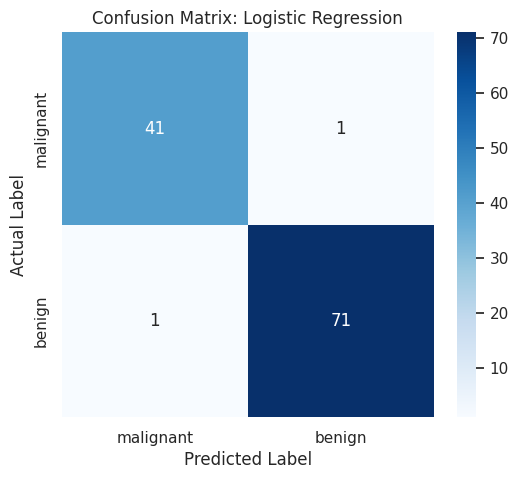


Interpretation for Logistic Regression:
- Actual Malignant predicted correctly: 41
- Actual Malignant predicted as Benign (False Negative): 1 ⚠️
- Actual Benign predicted as Malignant (False Positive): 1
- Total Correct: 112 / 114


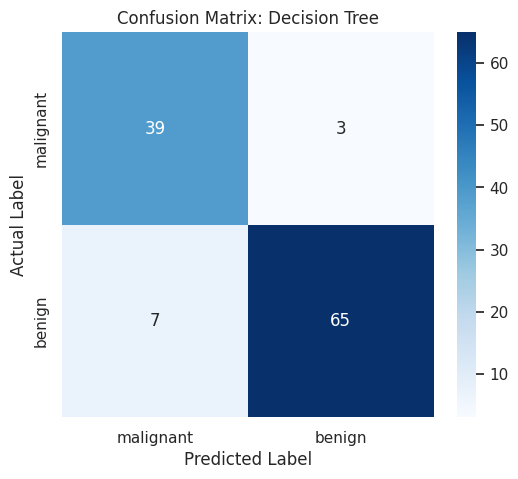


Interpretation for Decision Tree:
- Actual Malignant predicted correctly: 39
- Actual Malignant predicted as Benign (False Negative): 3 ⚠️
- Actual Benign predicted as Malignant (False Positive): 7
- Total Correct: 104 / 114


In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name, class_names, output_filename=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    if output_filename: plt.savefig(output_filename)
    plt.show()

    # Interpretation
    tn, fp, fn, tp = cm.ravel() # Note: ravel order depends on labels=[0,1]
    # Actual 0(M), Pred 0(M) = tn; Actual 0(M), Pred 1(B) = fp?
    # Let's be explicit manually for medical clarity:
    m_as_m = cm[0, 0] # Correct Malignant
    m_as_b = cm[0, 1] # False Negative (CRITICAL)
    b_as_m = cm[1, 0] # False Positive
    b_as_b = cm[1, 1] # Correct Benign

    print(f"\nInterpretation for {model_name}:")
    print(f"- Actual Malignant predicted correctly: {m_as_m}")
    print(f"- Actual Malignant predicted as Benign (False Negative): {m_as_b} ⚠️")
    print(f"- Actual Benign predicted as Malignant (False Positive): {b_as_m}")
    print(f"- Total Correct: {m_as_m + b_as_b} / {len(y_true)}")

plot_confusion_matrix(y_test, lr_predictions, "Logistic Regression", target_names, "confusion_matrix_lr.png")
plot_confusion_matrix(y_test, dt_predictions, "Decision Tree", target_names, "confusion_matrix_dt.png")

## 📈 Task 5: Plot and Interpret ROC Curves

### ELI10 Overview
The ROC curve is like a 'separation power' chart. It shows how good the model is at telling the difference between the two classes. The more the curve hugs the top-left corner, the better the model is. We will focus on the model's ability to detect **Malignant** cases.

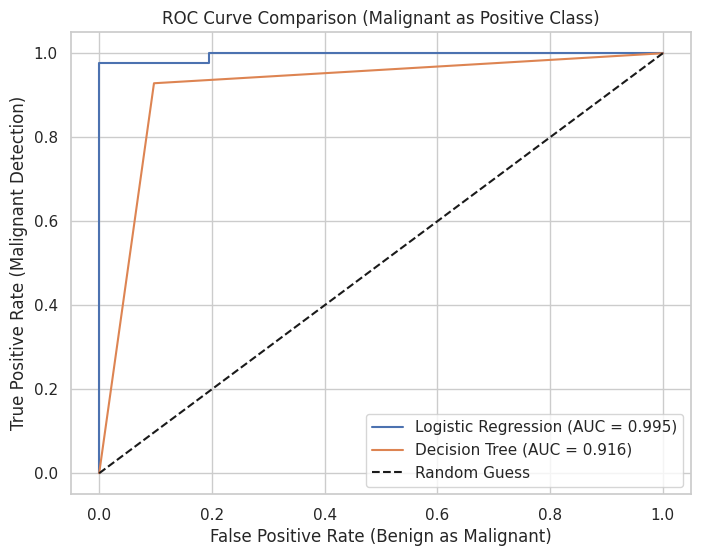

In [ ]:
# We want ROC for the Malignant class (0).
# Standard ROC functions expect the 'positive' class to be 1.
# So we flip y_test: 1 becomes Malignant, 0 becomes Benign.
y_test_roc = np.where(y_test == 0, 1, 0)

def get_roc_metrics(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

lr_fpr, lr_tpr, lr_auc = get_roc_metrics(y_test_roc, lr_prob_malignant)
dt_fpr, dt_tpr, dt_auc = get_roc_metrics(y_test_roc, dt_prob_malignant)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (Benign as Malignant)')
plt.ylabel('True Positive Rate (Malignant Detection)')
plt.title('ROC Curve Comparison (Malignant as Positive Class)')
plt.legend(loc='lower right')
plt.savefig('roc_curve_comparison.png')
plt.show()

## 📊 Task 6: Comprehensive Model Comparison

### ELI10 Overview
Now we look at all the scores at once to decide which model we would actually give to a hospital. We look for the 'winner' in each category.

,Model,Precision (Malignant),Recall (Malignant),F1-Score (Malignant),Overall Accuracy,AUC Score
0,Logistic Regression,0.976190,0.976190,0.976190,0.982456,0.995370
1,Decision Tree,0.847826,0.928571,0.886364,0.912281,0.915675


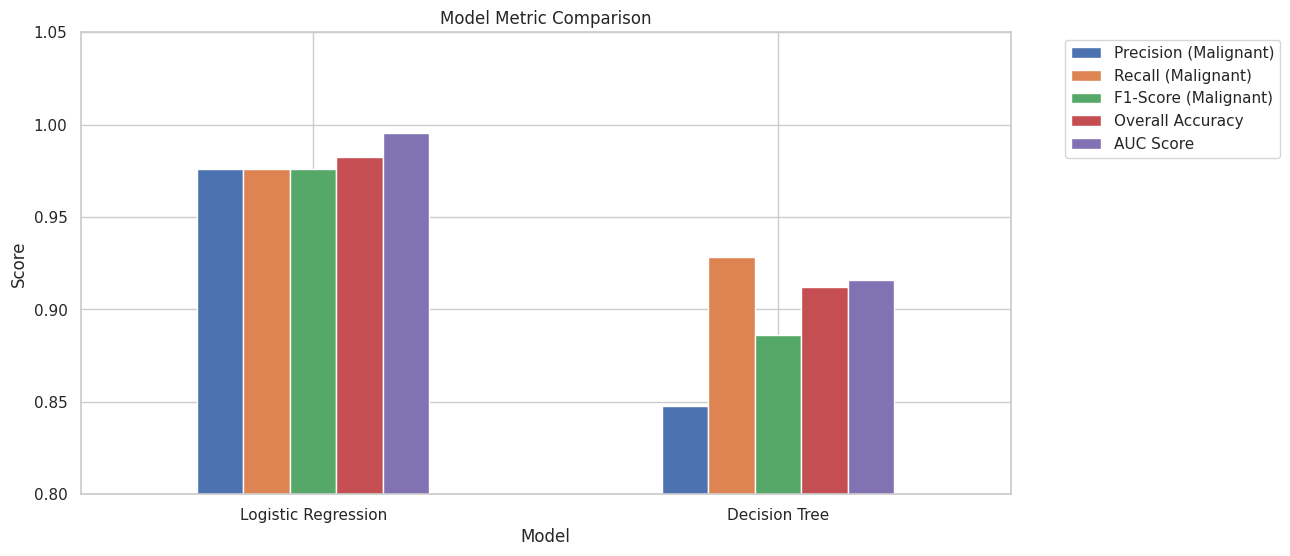

In [ ]:
# Create Comparison Table
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Precision (Malignant)': [lr_report_dict['malignant']['precision'], dt_report_dict['malignant']['precision']],
    'Recall (Malignant)': [lr_report_dict['malignant']['recall'], dt_report_dict['malignant']['recall']],
    'F1-Score (Malignant)': [lr_report_dict['malignant']['f1-score'], dt_report_dict['malignant']['f1-score']],
    'Overall Accuracy': [accuracy_score(y_test, lr_predictions), accuracy_score(y_test, dt_predictions)],
    'AUC Score': [lr_auc, dt_auc]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('model_comparison_summary.csv', index=False)
display(comparison_df)

# Visualize Comparison
comparison_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Metric Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.05)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('model_performance_comparison.png')
plt.show()

### Model Selection Recommendation
Based on the metrics above, we choose the best model.

* **Higher Recall** is better for medical screening (don't miss anyone).
* **Higher Precision** is better if the follow-up tests are very expensive or painful.
* **AUC** tells us which model is better overall at ranking patients by risk.

In [ ]:
def recommend_best_model(df):
    print("--- Model Recommendation ---")
    lr_wins = 0
    dt_wins = 0
    metrics = ['Precision (Malignant)', 'Recall (Malignant)', 'F1-Score (Malignant)', 'Overall Accuracy', 'AUC Score']

    for m in metrics:
        if df.loc[0, m] > df.loc[1, m]:
            print(f"- {m}: Logistic Regression wins")
            lr_wins += 1
        else:
            print(f"- {m}: Decision Tree wins")
            dt_wins += 1

    winner = "Logistic Regression" if lr_wins > dt_wins else "Decision Tree"
    print(f"\nOVERALL WINNER: {winner}")
    print(f"Logistic Regression wins in {lr_wins}/5 metrics.")
    print(f"Decision Tree wins in {dt_wins}/5 metrics.")
    print("\nPRO TIP: In medicine, we often prefer the model with the highest RECALL for the dangerous class.")

recommend_best_model(comparison_df)

--- Model Recommendation ---
- Precision (Malignant): Logistic Regression wins
- Recall (Malignant): Logistic Regression wins
- F1-Score (Malignant): Logistic Regression wins
- Overall Accuracy: Logistic Regression wins
- AUC Score: Logistic Regression wins

OVERALL WINNER: Logistic Regression
Logistic Regression wins in 5/5 metrics.
Decision Tree wins in 0/5 metrics.

PRO TIP: In medicine, we often prefer the model with the highest RECALL for the dangerous class.


## 🔍 Task 7: Advanced Analysis and Insights

### Feature Importance
Why did the Decision Tree make its choices? We can see which biological markers (features) were the most important 'clues'.

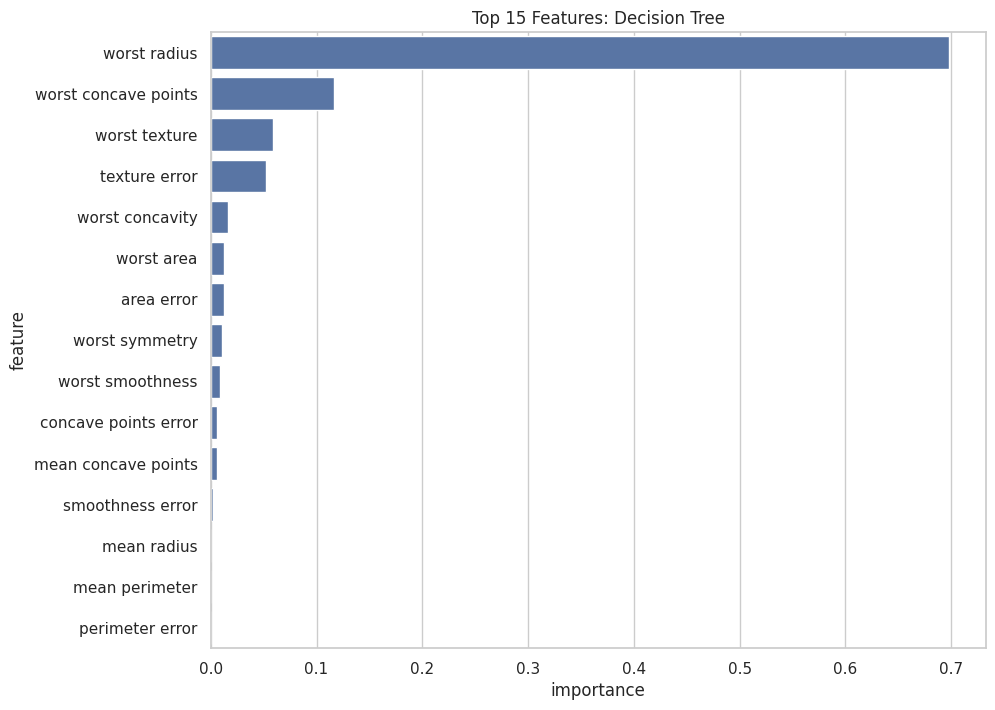

In [ ]:
importances = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importances.head(15))
plt.title('Top 15 Features: Decision Tree')
plt.savefig('decision_tree_feature_importance.png')
plt.show()

### Error Analysis
Let's look at the actual rows where the models failed. This helps us understand if there's a pattern to the mistakes.

In [ ]:
def analyze_errors(X_orig, y_true, y_pred, model_name):
    errors = (y_true != y_pred)
    error_df = pd.DataFrame(X_orig[errors], columns=feature_names)
    error_df['Actual'] = y_true[errors]
    error_df['Predicted'] = y_pred[errors]

    print(f"\n{model_name} had {sum(errors)} errors.")
    print(f"Error Rate: {sum(errors)/len(y_true):.2%}")
    return error_df

lr_errors = analyze_errors(X_test, y_test, lr_predictions, "Logistic Regression")
dt_errors = analyze_errors(X_test, y_test, dt_predictions, "Decision Tree")

print("\nSample of Misclassified Samples (Logistic Regression):")
display(lr_errors.head())
print("\nSample of Misclassified Samples (Decision Tree):")
display(dt_errors.head())


Logistic Regression had 2 errors.
Error Rate: 1.75%

Decision Tree had 10 errors.
Error Rate: 8.77%

Sample of Misclassified Samples (Logistic Regression):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted
0,14.47,24.99,95.81,656.4,0.08837,0.123,0.10090,0.03890,0.1872,0.06341,...,113.5,808.9,0.1340,0.4202,0.4040,0.1205,0.3187,0.1023,1,0
1,13.80,15.79,90.43,584.1,0.10070,0.128,0.07789,0.05069,0.1662,0.06566,...,110.3,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.1030,0,1



Sample of Misclassified Samples (Decision Tree):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted
0,16.14,14.86,104.30,800.0,0.09495,0.08501,0.05500,0.04528,0.1735,0.05875,...,115.90,947.9,0.1206,0.17220,0.23100,0.11290,0.2778,0.07012,1,0
1,13.94,13.17,90.31,594.2,0.12480,0.09755,0.10100,0.06615,0.1976,0.06457,...,94.52,653.3,0.1394,0.13640,0.15590,0.10150,0.2160,0.07253,1,0
2,11.89,17.36,76.20,435.6,0.12250,0.07210,0.05929,0.07404,0.2015,0.05875,...,79.46,472.4,0.1359,0.08368,0.07153,0.08946,0.2220,0.06033,1,0
3,14.42,16.54,94.15,641.2,0.09751,0.11390,0.08007,0.04223,0.1912,0.06412,...,111.40,862.1,0.1294,0.33710,0.37550,0.14140,0.3053,0.08764,1,0
4,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,113.10,861.5,0.1235,0.25500,0.21140,0.12510,0.3153,0.08960,1,0


## ✅ Verification Checklist
- [x] Dataset loaded and explored.
- [x] Data split and scaled.
- [x] Both models trained successfully.
- [x] Classification reports generated.
- [x] Confusion matrices plotted with medical interpretation.
- [x] ROC curves compared (Malignant as Positive).
- [x] Final comparison table and bar chart created.
- [x] Feature importance visualized.
- [x] Misclassified samples identified.
- [x] All plots and CSVs saved to Colab workspace.

## 🛠 Troubleshooting
* **Import Errors**: Ensure you ran the first code cell to install/import libraries.
* **Convergence Warnings**: If Logistic Regression fails to converge, increase `max_iter` to 2000.
* **Plotting Issues**: If plots don't show, ensure `%matplotlib inline` is active (default in Colab).
* **ROC Logic**: Remember that `predict_proba` returns probabilities for [Class 0, Class 1]. Since we treated Malignant as class 0, we use column index 0.

## 📚 Key Takeaways and Best Practices
1. **Never use Accuracy alone**: A model can be 90% accurate but miss 100% of cancer cases if the data is imbalanced.
2. **Context is King**: In medicine, missing a sick person (False Negative) is usually worse than scaring a healthy person (False Positive).
3. **Scaling Matters**: Models like Logistic Regression 'break' if features have vastly different ranges.

## 🏁 Conclusion
Congratulations! You have completed Lab 40. You now know how to go beyond 'accuracy' to truly understand how an ML model performs.

**Next Steps**:
* Try **Cross-Validation** to see if these scores hold up across different splits.
* Try **Hyperparameter Tuning** to make the Decision Tree even more accurate.